## IMPORT LIBRARY

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## DATA CLEANING

In [ ]:
df = pd.read_csv("UN_SDG.csv")
df

,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,FREQ_LABEL,REF_AREA,REF_AREA_LABEL,INDICATOR,INDICATOR_LABEL,SEX,...,UNIT_MULT,UNIT_MULT_LABEL,UNIT_TYPE,UNIT_TYPE_LABEL,TIME_FORMAT,TIME_FORMAT_LABEL,OBS_STATUS,OBS_STATUS_LABEL,OBS_CONF,OBS_CONF_LABEL
0,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,HTI,Haiti,UN_SDG_AG_FPA_IFPI,2.c.1 Indicator of food price anomalies,_Z,...,0,Units,IX,Index,602,CCYY,A,Normal value,PU,Public
1,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,HTI,Haiti,UN_SDG_AG_FPA_IFPI,2.c.1 Indicator of food price anomalies,_Z,...,0,Units,IX,Index,602,CCYY,A,Normal value,PU,Public
2,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,HTI,Haiti,UN_SDG_AG_FPA_IFPI,2.c.1 Indicator of food price anomalies,_Z,...,0,Units,IX,Index,602,CCYY,A,Normal value,PU,Public
3,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,HTI,Haiti,UN_SDG_AG_FPA_IFPI,2.c.1 Indicator of food price anomalies,_Z,...,0,Units,IX,Index,602,CCYY,A,Normal value,PU,Public
4,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,HTI,Haiti,UN_SDG_AG_FPA_IFPI,2.c.1 Indicator of food price anomalies,_Z,...,0,Units,IX,Index,602,CCYY,A,Normal value,PU,Public
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53646,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,BFA,Burkina Faso,UN_SDG_SI_AGR_LBU,2.3.2 Average income of small-scale food produ...,_T,...,6,Millions,CUR,Currency,602,CCYY,O,Missing value,PU,Public
53647,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,BFA,Burkina Faso,UN_SDG_SI_AGR_LBU,2.3.2 Average income of small-scale food produ...,F,...,6,Millions,CUR,Currency,602,CCYY,O,Missing value,PU,Public
53648,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,BFA,Burkina Faso,UN_SDG_SI_AGR_LBU,2.3.2 Average income of small-scale food produ...,F,...,6,Millions,CUR,Currency,602,CCYY,O,Missing value,PU,Public
53649,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,BFA,Burkina Faso,UN_SDG_SI_AGR_LBU,2.3.2 Average income of small-scale food produ...,_T,...,6,Millions,CUR,Currency,602,CCYY,O,Missing value,PU,Public


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53651 entries, 0 to 53650
Data columns (total 37 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   STRUCTURE               53651 non-null  object 
 1   STRUCTURE_ID            53651 non-null  object 
 2   ACTION                  53651 non-null  object 
 3   FREQ                    53651 non-null  object 
 4   FREQ_LABEL              53651 non-null  object 
 5   REF_AREA                53651 non-null  object 
 6   REF_AREA_LABEL          53651 non-null  object 
 7   INDICATOR               53651 non-null  object 
 8   INDICATOR_LABEL         53651 non-null  object 
 9   SEX                     53651 non-null  object 
 10  SEX_LABEL               53651 non-null  object 
 11  AGE                     53651 non-null  object 
 12  AGE_LABEL               53651 non-null  object 
 13  URBANISATION            53651 non-null  object 
 14  URBANISATION_LABEL      53651 non-null

#### -PENGAMBILAN FITUR YANG PENTING

In [ ]:
df = df[["REF_AREA_LABEL", "TIME_PERIOD", "OBS_VALUE", "INDICATOR_LABEL", "COMP_BREAKDOWN_1_LABEL"]]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53651 entries, 0 to 53650
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   REF_AREA_LABEL          53651 non-null  object 
 1   TIME_PERIOD             53651 non-null  int64  
 2   OBS_VALUE               36927 non-null  float64
 3   INDICATOR_LABEL         53651 non-null  object 
 4   COMP_BREAKDOWN_1_LABEL  53651 non-null  object 
dtypes: float64(1), int64(1), object(3)
memory usage: 2.0+ MB


#### -PENGHAPUSAN MISSING VALUES

In [ ]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
REF_AREA_LABEL                0
TIME_PERIOD                   0
OBS_VALUE                 16724
INDICATOR_LABEL               0
COMP_BREAKDOWN_1_LABEL        0
dtype: int64


In [ ]:
# Remove rows where ANY column has missing values
df_clean = df.dropna()
print(f"Original shape: {df.shape}")
print(f"After removing missing values: {df_clean.shape}")

Original shape: (53651, 5)
After removing missing values: (36927, 5)


#### -PENGHAPUSAN DATA DUPLIKAT

In [ ]:
df_clean2 = df_clean.drop_duplicates()
print(f"Original shape: {df_clean.shape}")
print(f"After removing missing values: {df_clean2.shape}")

Original shape: (36927, 5)
After removing missing values: (36836, 5)


In [ ]:
unique_indicators = df_clean2['INDICATOR_LABEL'].unique()
print(f"Number of unique INDICATOR values: {len(unique_indicators)}")
print("Unique values:")
print(unique_indicators)

Number of unique INDICATOR values: 10
Unique values:
['2.c.1 Indicator of food price anomalies'
 '2.4.1 Proportion of agricultural area under productive and sustainable agriculture'
 '2.a.1 The agriculture orientation index for government expenditures'
 '2.b.1 Agricultural export subsidies'
 '2.a.2 Total official flows (official development assistance plus other official flows) to the agriculture sector'
 '2.5.1 Number of (a) plant and (b) animal genetic resources for food and agriculture secured in either medium- or long-term conservation facilities'
 '2.5.2 Proportion of local breeds classified as being at risk of extinction'
 '2.3.1 Volume of production per labour unit by classes of farming/pastoral/forestry enterprise size'
 '2.2.2 Prevalence of malnutrition (weight for height >+2 or <-2 standard deviation from the median of the WHO Child Growth Standards) among children under 5Â\xa0years of age, by type (wasting and overweight)'
 '2.3.2 Average income of small-scale food producers

In [ ]:
df_clean2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 36836 entries, 0 to 53641
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   REF_AREA_LABEL          36836 non-null  object 
 1   TIME_PERIOD             36836 non-null  int64  
 2   OBS_VALUE               36836 non-null  float64
 3   INDICATOR_LABEL         36836 non-null  object 
 4   COMP_BREAKDOWN_1_LABEL  36836 non-null  object 
dtypes: float64(1), int64(1), object(3)
memory usage: 1.7+ MB


#### -KONVERSI OBJECT KE INTEGER TYPE PADA FITUR TIME_PERIOD

In [ ]:
df_clean2['TIME_PERIOD'] = df_clean2['TIME_PERIOD'].astype(int)
df_clean2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 36836 entries, 0 to 53641
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   REF_AREA_LABEL          36836 non-null  object 
 1   TIME_PERIOD             36836 non-null  int64  
 2   OBS_VALUE               36836 non-null  float64
 3   INDICATOR_LABEL         36836 non-null  object 
 4   COMP_BREAKDOWN_1_LABEL  36836 non-null  object 
dtypes: float64(1), int64(1), object(3)
memory usage: 1.7+ MB


/tmp/ipython-input-1401102522.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean2['TIME_PERIOD'] = df_clean2['TIME_PERIOD'].astype(int)


In [ ]:
df_clean2.sample(5)

,REF_AREA_LABEL,TIME_PERIOD,OBS_VALUE,INDICATOR_LABEL,COMP_BREAKDOWN_1_LABEL
41483,Latvia,2005,5.60,2.2.2 Prevalence of malnutrition (weight for h...,Malnutrition Type : Overweight
5179,Qatar,2021,100.00,2.4.1 Proportion of agricultural area under pr...,Not Applicable
6776,"Congo, Dem. Rep.",2008,0.13,2.a.1 The agriculture orientation index for go...,Not Applicable
10725,Australia,2011,0.00,2.b.1 Agricultural export subsidies,Not Applicable
35701,Central and Southern Asia (SDG aggregate),2003,2.80,2.2.2 Prevalence of malnutrition (weight for h...,Malnutrition Type : Overweight


In [ ]:
unique_indicators2 = df_clean2['COMP_BREAKDOWN_1_LABEL'].unique()
print(f"Number of unique COMP_BREAKDOWN_1_LABEL values: {len(unique_indicators2)}")
print("Unique values:")
print(unique_indicators2)

Number of unique COMP_BREAKDOWN_1_LABEL values: 9
Unique values:
['Sub-indicator: Consumer Food Price Index'
 'Sub-indicator: Type of product' 'Not Applicable'
 'Reconsitution Breeds : Local' 'Reconsitution Breeds : Transboundary'
 'Food Producer Type: Small-scale' 'Food Producer Type: Large-scale'
 'Malnutrition Type : Wasting' 'Malnutrition Type : Overweight']


In [ ]:
unique_indicators3 = df_clean2['REF_AREA_LABEL'].unique()
print(f"Number of unique REF_AREA_LABEL values: {len(unique_indicators3)}")
print("Unique values:")
print(unique_indicators3)

Number of unique REF_AREA_LABEL values: 259
Unique values:
['Haiti' 'Honduras' 'Hungary' 'Iceland' 'Afghanistan' 'India' 'Albania'
 'Indonesia' 'Iran, Islamic Rep.' 'Algeria' 'Andorra' 'Angola' 'Iraq'
 'Antigua and Barbuda' 'Ireland' 'Israel' 'Azerbaijan' 'Italy'
 "Cote d'Ivoire" 'Argentina' 'Jamaica' 'Australia' 'Japan' 'Kazakhstan'
 'Austria' 'Bahamas, The' 'Bahrain' 'Jordan' 'Bangladesh' 'Kenya'
 'Korea, Rep.' 'Armenia' 'Kuwait' 'Kyrgyz Republic' 'Barbados' 'Lao PDR'
 'Belgium' 'Lebanon' 'Lesotho' 'Bermuda' 'Latvia' 'Liberia' 'Libya'
 'Bhutan' 'Lithuania' 'Bolivia' 'Luxembourg' 'Bosnia and Herzegovina'
 'Madagascar' 'Botswana' 'Brazil' 'Belize' 'Solomon Islands' 'Malawi'
 'Malaysia' 'Maldives' 'Mali' 'British Virgin Islands' 'Brunei Darussalam'
 'Malta' 'Bulgaria' 'Martinique' 'Myanmar' 'Burundi' 'Belarus' 'Cambodia'
 'Mauritania' 'Cameroon' 'Canada' 'Cabo Verde' 'Cayman Islands'
 'Sri Lanka' 'Chad' 'Chile' 'China' 'Colombia' 'Mauritius' 'Comoros'
 'Mexico' 'Congo, Rep.' 'Mongolia' 

In [ ]:
unique_indicators4 = df_clean2['TIME_PERIOD'].unique()
print(f"Number of unique TIME_PERIOD values: {len(unique_indicators4)}")
print("Unique values:")
print(unique_indicators4)

Number of unique TIME_PERIOD values: 30
Unique values:
[2018 2019 2020 2021 2022 2023 2010 2011 2012 2013 2014 2015 2016 2017
 2024 2001 2002 2003 2004 2005 2006 2007 2008 2009 1995 1996 1997 1998
 1999 2000]


## EXPLORATORY DATA ANALYSIS (EDA)

#### -VISUALISASI DISTRIBUSI UNIQUE VALUES

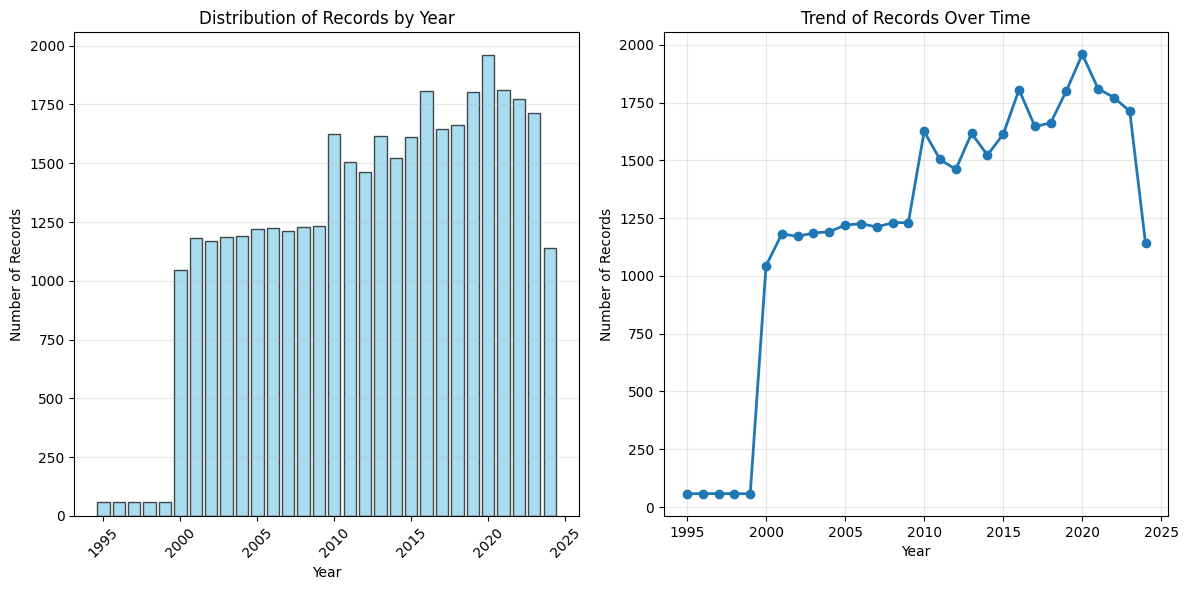

In [ ]:
plt.figure(figsize=(12, 6))

# Simple count plot
year_counts = df_clean2['TIME_PERIOD'].value_counts().sort_index()

plt.subplot(1, 2, 1)
plt.bar(year_counts.index, year_counts.values, color='skyblue', alpha=0.7, edgecolor='black')
plt.title('Distribution of Records by Year')
plt.xlabel('Year')
plt.ylabel('Number of Records')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Line plot to see trends
plt.subplot(1, 2, 2)
plt.plot(year_counts.index, year_counts.values, marker='o', linewidth=2, markersize=6)
plt.title('Trend of Records Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Records')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

/tmp/ipython-input-2923115937.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['OBS_VALUE_buckets'] = pd.cut(df['OBS_VALUE'], bins=10)


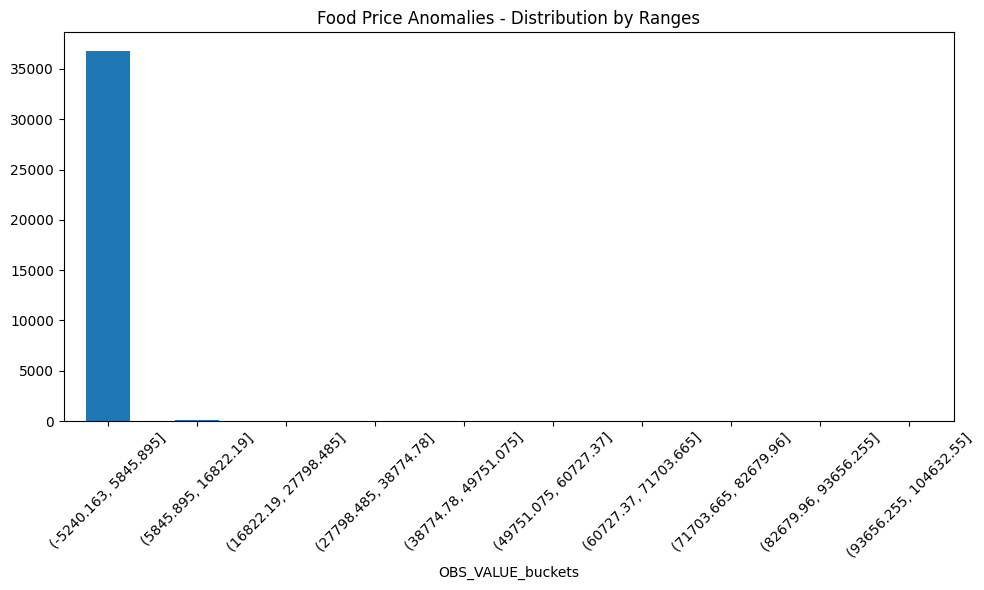

In [ ]:
# If you had a numerical column with many unique values
if df_clean2['OBS_VALUE'].nunique() > 50:
    plt.figure(figsize=(10, 6))
    # Bucket into ranges
    df['OBS_VALUE_buckets'] = pd.cut(df['OBS_VALUE'], bins=10)
    df['OBS_VALUE_buckets'].value_counts().sort_index().plot(kind='bar')
    plt.title('Food Price Anomalies - Distribution by Ranges')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

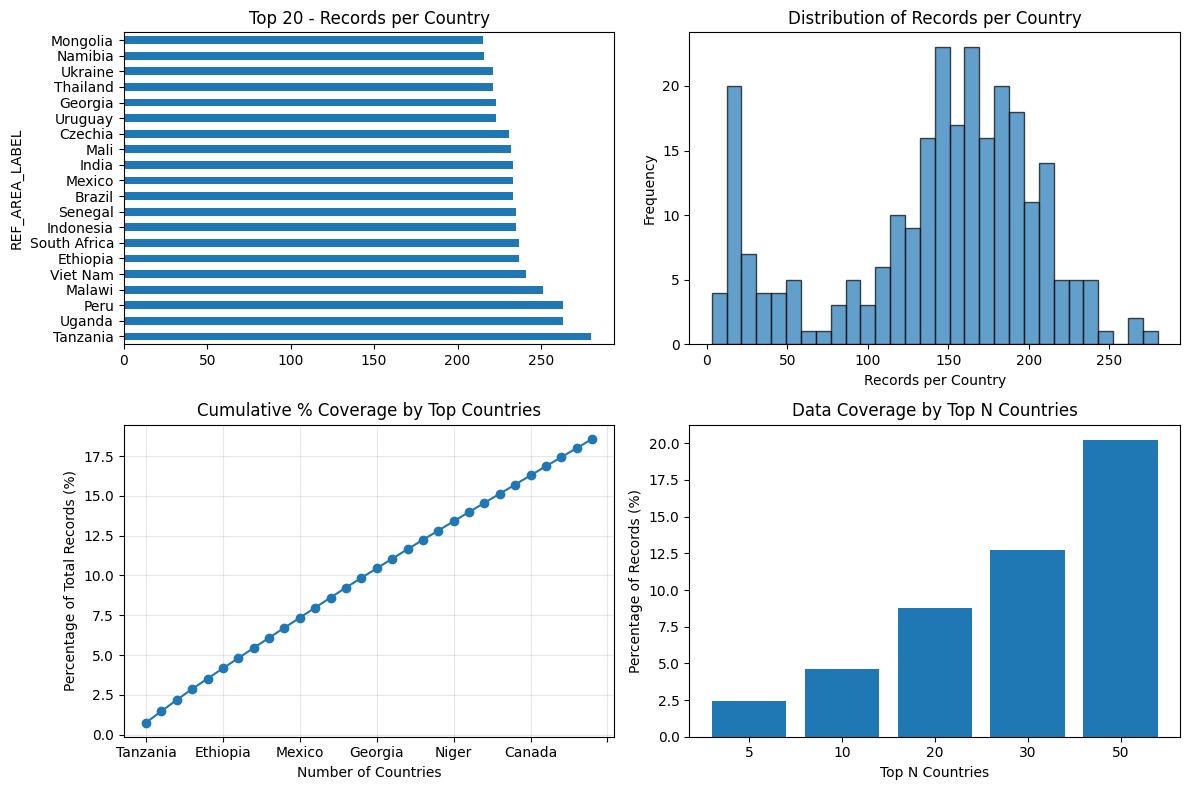

In [ ]:
# For high cardinality columns, show distribution characteristics
high_card_col = 'REF_AREA_LABEL'  # Example
if df_clean2[high_card_col].nunique() > 50:
    value_counts = df_clean2[high_card_col].value_counts()

    plt.figure(figsize=(12, 8))

    # Plot 1: Records per entity (sorted)
    plt.subplot(2, 2, 1)
    value_counts.head(20).plot(kind='barh')
    plt.title('Top 20 - Records per Country')

    # Plot 2: Distribution of record counts
    plt.subplot(2, 2, 2)
    plt.hist(value_counts.values, bins=30, alpha=0.7, edgecolor='black')
    plt.title('Distribution of Records per Country')
    plt.xlabel('Records per Country')
    plt.ylabel('Frequency')

    # Plot 3: Cumulative coverage
    plt.subplot(2, 2, 3)
    cumulative_pct = value_counts.cumsum() / value_counts.sum() * 100
    cumulative_pct.head(30).plot(kind='line', marker='o')
    plt.title('Cumulative % Coverage by Top Countries')
    plt.xlabel('Number of Countries')
    plt.ylabel('Percentage of Total Records (%)')
    plt.grid(True, alpha=0.3)

    # Plot 4: Top N coverage
    plt.subplot(2, 2, 4)
    top_n = [5, 10, 20, 30, 50]
    coverage_pct = [value_counts.head(n).sum()/len(df)*100 for n in top_n]
    plt.bar(range(len(top_n)), coverage_pct)
    plt.xticks(range(len(top_n)), top_n)
    plt.title('Data Coverage by Top N Countries')
    plt.xlabel('Top N Countries')
    plt.ylabel('Percentage of Records (%)')

    plt.tight_layout()
    plt.show()

In [ ]:
# Get all unique indicators
unique_indicators = df_clean2['INDICATOR_LABEL'].unique()
print(f"Found {len(unique_indicators)} unique indicators:")
for indicator in unique_indicators:
    print(f"  - {indicator}")

# Create a dictionary to store separate dataframes
indicator_dfs = {}

for indicator in unique_indicators:
    indicator_dfs[indicator] = df_clean2[df_clean2['INDICATOR_LABEL'] == indicator].copy()
    print(f"{indicator}: {indicator_dfs[indicator].shape[0]} records")

# CONTINUATION: Create separate variables for each indicator with cleaned names and reset index
import re

for indicator_name, indicator_df in indicator_dfs.items():
    # Create a clean variable name - remove special characters and spaces
    var_name = indicator_name

    # Remove "2.c.1 " prefix if present
    var_name = re.sub(r'^2\.c\.1\s*', '', var_name)

    # Remove "Indicator of " prefix if present
    var_name = re.sub(r'^Indicator of\s*', '', var_name)

    # Remove all special characters: (, ), <, >, +, -, =, etc.
    var_name = re.sub(r'[^a-zA-Z0-9\s]', '', var_name)

    # Replace spaces with underscores and convert to lowercase
    var_name = var_name.replace(' ', '_').lower()

    # Add df_ prefix
    var_name = f"df_{var_name}"

    # Reset the index of the dataframe
    indicator_df_reset = indicator_df.reset_index(drop=True)

    # Create the variable in the global scope
    globals()[var_name] = indicator_df_reset

    print(f"Created variable: {var_name} with shape {indicator_df_reset.shape}")

# Now you can access each dataframe directly!
print("\nYou can now access each dataframe directly:")
print("Available dataframes:")
for var in sorted([v for v in globals() if v.startswith('df_')]):
    df_obj = globals()[var]
    print(f"  - {var} (shape: {df_obj.shape})")

Found 10 unique indicators:
  - 2.c.1 Indicator of food price anomalies
  - 2.4.1 Proportion of agricultural area under productive and sustainable agriculture
  - 2.a.1 The agriculture orientation index for government expenditures
  - 2.b.1 Agricultural export subsidies
  - 2.a.2 Total official flows (official development assistance plus other official flows) to the agriculture sector
  - 2.5.1 Number of (a) plant and (b) animal genetic resources for food and agriculture secured in either medium- or long-term conservation facilities
  - 2.5.2 Proportion of local breeds classified as being at risk of extinction
  - 2.3.1 Volume of production per labour unit by classes of farming/pastoral/forestry enterprise size
  - 2.2.2 Prevalence of malnutrition (weight for height >+2 or <-2 standard deviation from the median of the WHO Child Growth Standards) among children under 5Â years of age, by type (wasting and overweight)
  - 2.3.2 Average income of small-scale food producers, by sex and indi

## EKSPORT DATASET UNTUK INDIKATOR UTAMA

In [ ]:
df_food_price_anomalies.to_csv("food_price_anomalies.csv", index=False)

## FEATURE ENGINEERING